## Imports

In [33]:
import tensorflow as tf
import numpy as np
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import matplotlib.pyplot as plt
from collections import Counter
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModel
import torch
import pandas as pd
# nltk.download('stopwords')

## Loading and cleaning 

In [34]:
df = pd.read_csv("/Users/maryamsaad/Documents/arabic_poetry_generator/datasets/poetry_generation_dataset.csv"
                 
                 )
TEXT_COLUMN = "البيت"

In [35]:
# def remove_stopwords(arabic_text):
#     arabic_stopwords = set(stopwords.words('arabic'))
#     tokens = word_tokenize(arabic_text)
#     stopwords_removed = [word for word in tokens if word in arabic_stopwords]
#     filtered_tokens = [word for word in tokens if word not in arabic_stopwords]
#     filtered_text = " ".join(filtered_tokens)
#     return filtered_text, len(stopwords_removed)

In [36]:
arabic_diacritics = re.compile(r"""
    ّ    | َ    | ً    | ُ    | ٌ    |
    ِ    | ٍ    | ْ    | ـ""", re.VERBOSE)


def remove_diacritics(text):
    return arabic_diacritics.sub('', text)

In [37]:
def normalize_arabic(text):
    text = re.sub("[إأآا]", "ا", text)
    text = re.sub("ى", "ي", text)
    text = re.sub("ؤ", "ء", text)
    text = re.sub("ئ", "ء", text)
    text = re.sub("ة", "ه", text)
    text = re.sub("گ", "ك", text)
    text = re.sub("ء", " ", text)
    return text

In [38]:
def remove_non_arabic(text):
    return re.sub(r"[^ء-ي\s]", " ", text)

def clean_spaces(text):
    return re.sub(r"\s+", " ", text).strip()
def remove_numbers_and_hashtags(text):
    return re.sub(r"[0-9#]+", " ", text)

def clean_text(text):
    text = remove_diacritics(text)
    text = normalize_arabic(text)
    text = remove_non_arabic(text)
    text = remove_numbers_and_hashtags(text)  
    text = clean_spaces(text)
    return text

In [39]:
print("Cleaning text...")
df["clean_text"] = df[TEXT_COLUMN].astype(str).apply(clean_text)
initial_count = len(df)
df = df[df["clean_text"].str.len() > 0].copy()
print(f"Removed {initial_count - len(df)} empty rows. Remaining rows: {len(df)}")

Cleaning text...
Removed 1 empty rows. Remaining rows: 777258


## Visualizations and Statistics

In [41]:
df.dropna(inplace=True)

In [42]:
df.to_csv("/Users/maryamsaad/Documents/arabic_poetry_generator/datasets/cleaned_v2_poetry_dataset.csv", index=False)

In [27]:
df['word_count']=df['clean_text'].apply(lambda x: len(x.split()))


Average word count: 9.36
Median word count: 10.00
Max word count: 691
Standard deviation of word count: 2.62


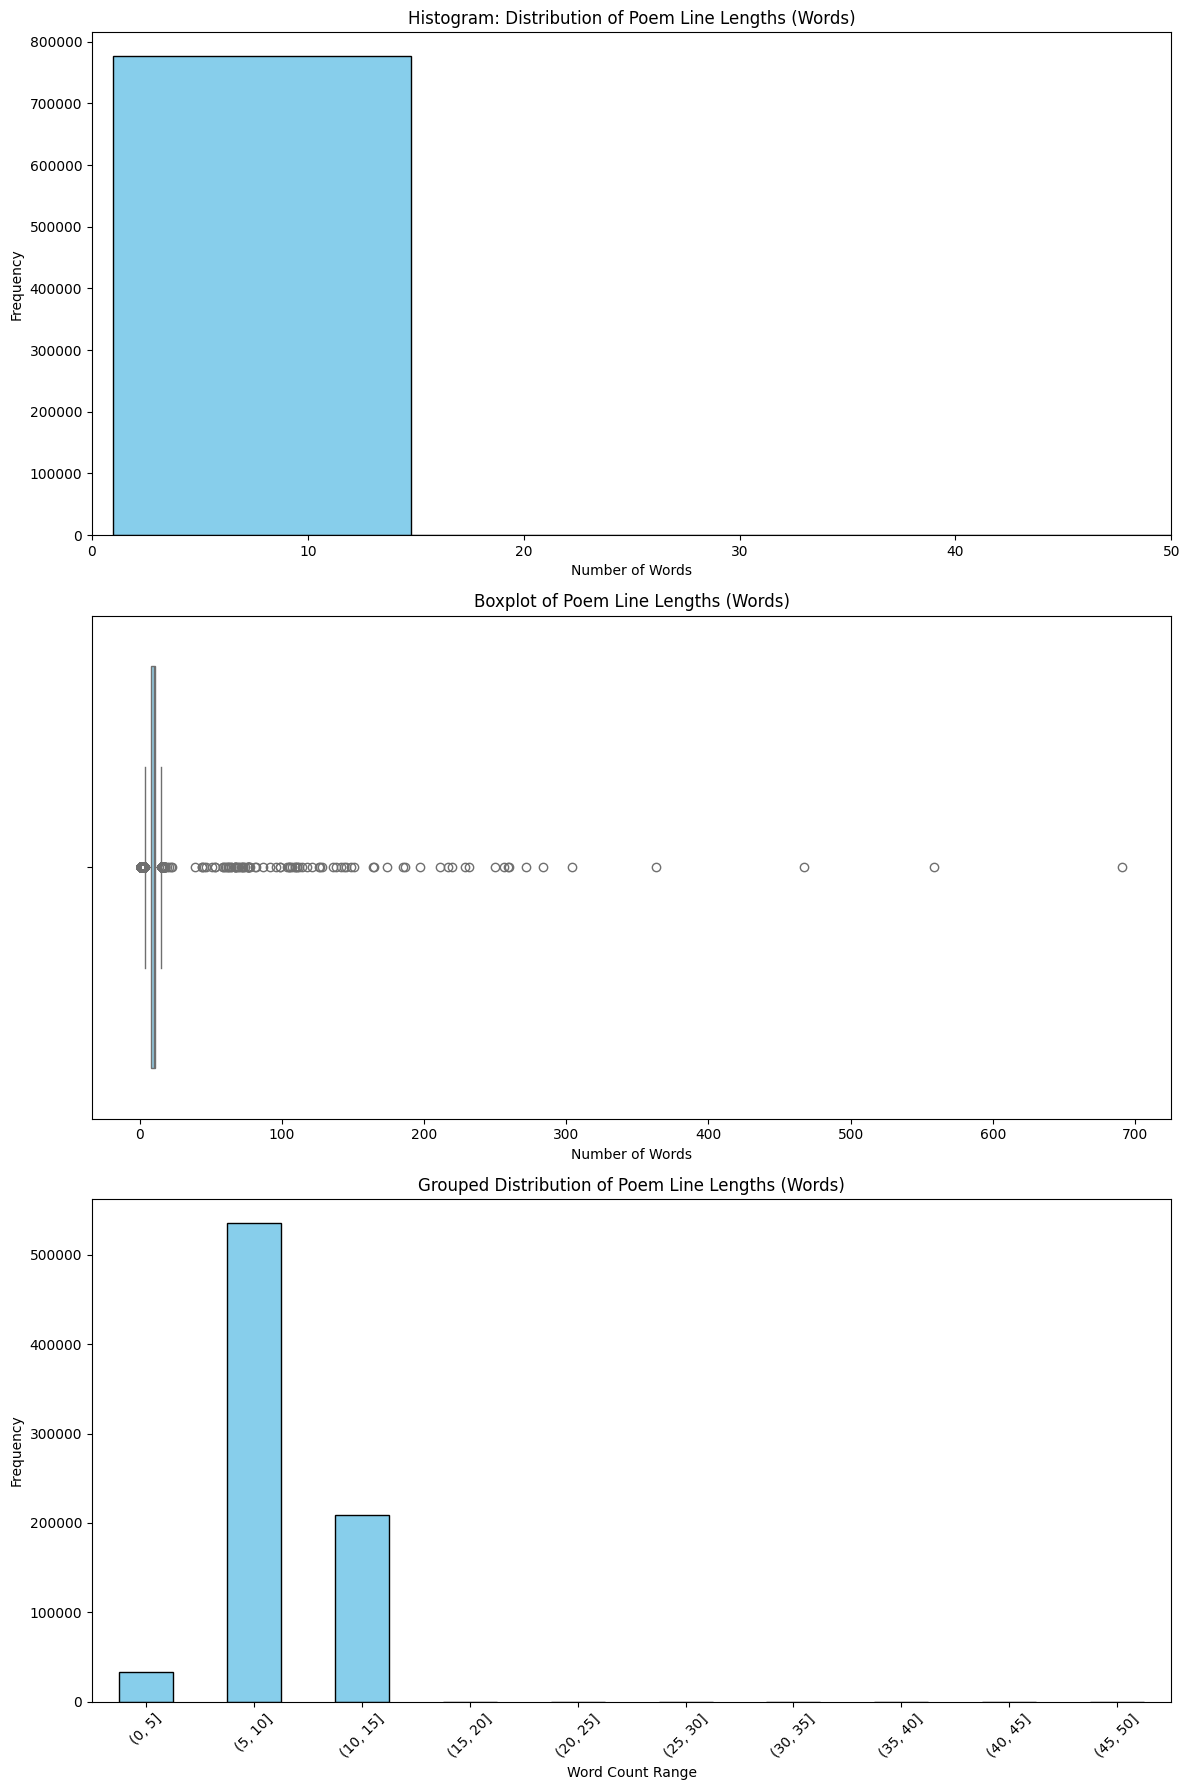

In [28]:
# ---- Stats ----
print(f"Average word count: {df['word_count'].mean():.2f}")
print(f"Median word count: {df['word_count'].median():.2f}")
print(f"Max word count: {df['word_count'].max()}")
print(f"Standard deviation of word count: {df['word_count'].std():.2f}")

# ---- Binning ----
bins = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
df['word_count_bin'] = pd.cut(df['word_count'], bins=bins)
bin_counts = df['word_count_bin'].value_counts().sort_index()

# ---- Combined Figure ----
fig, axes = plt.subplots(3, 1, figsize=(12, 18))

# 1️⃣ Histogram
axes[0].hist(df['word_count'], bins=50, color='skyblue', edgecolor='black')
axes[0].set_title('Histogram: Distribution of Poem Line Lengths (Words)')
axes[0].set_xlabel('Number of Words')
axes[0].set_ylabel('Frequency')
axes[0].set_xlim(0, 50)

# 2️⃣ Boxplot
sns.boxplot(x=df['word_count'], color='skyblue', ax=axes[1])
axes[1].set_title('Boxplot of Poem Line Lengths (Words)')
axes[1].set_xlabel('Number of Words')

# 3️⃣ Binned Bar Chart
bin_counts.plot(kind='bar', color='skyblue', edgecolor='black', ax=axes[2])
axes[2].set_title('Grouped Distribution of Poem Line Lengths (Words)')
axes[2].set_xlabel('Word Count Range')
axes[2].set_ylabel('Frequency')
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()


In [29]:
MAX_SEQUENCE_LENGTH = 10
MIN_SEQUENCE_LENGTH = 6
df = df[df['word_count'] <= MAX_SEQUENCE_LENGTH]
df = df[df['word_count'] >= MIN_SEQUENCE_LENGTH]
print(f"Dataset size after filtering: {len(df)} rows")

Dataset size after filtering: 535188 rows


In [30]:
all_text = " ".join(df["clean_text"].astype(str))
unique_chars = set(all_text)
print(f"Unique characters in dataset: {len(unique_chars)}")
print(len(sorted(list(unique_chars))))

Unique characters in dataset: 29
29


In [31]:
print(sorted(list(unique_chars)))

[' ', 'ا', 'ب', 'ت', 'ث', 'ج', 'ح', 'خ', 'د', 'ذ', 'ر', 'ز', 'س', 'ش', 'ص', 'ض', 'ط', 'ظ', 'ع', 'غ', 'ف', 'ق', 'ك', 'ل', 'م', 'ن', 'ه', 'و', 'ي']


In [32]:
# Save the cleaned dataset
output_path = "../datasets/cleaned_poetry_dataset.csv"
df.to_csv(output_path, index=False)
print(f"Cleaned dataset saved to {output_path}")

Cleaned dataset saved to ../datasets/cleaned_poetry_dataset.csv


In [15]:
print("Counting vocabulary...")
word_counts = Counter()
df['clean_text'].str.split().apply(word_counts.update)

vocab_size = len(word_counts)
total_words = sum(word_counts.values())

print(f"Total words in dataset: {total_words:,}")
print(f"Vocabulary size (unique words): {vocab_size:,}")


Counting vocabulary...
Total words in dataset: 4,711,738
Vocabulary size (unique words): 351,983


Words appearing only once: 170,984 (48.6% of vocab)


/var/folders/c2/f9lh6rmd4q1648_pfl1636zw0000gn/T/ipykernel_47142/1644090733.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=words, y=counts, palette='viridis')


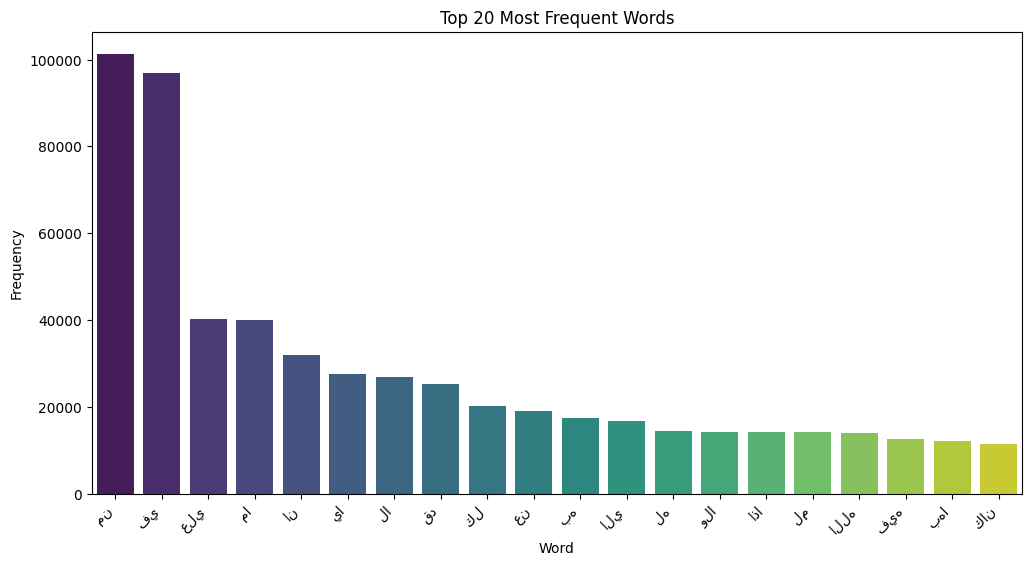

In [16]:
single_occurrence_words = sum(1 for count in word_counts.values() if count == 1)
print(f"Words appearing only once: {single_occurrence_words:,} ({single_occurrence_words/vocab_size:.1%} of vocab)")
top_words = word_counts.most_common(20)
words = [w[0] for w in top_words]
counts = [w[1] for w in top_words]

plt.figure(figsize=(12, 6))
sns.barplot(x=words, y=counts, palette='viridis')
plt.title('Top 20 Most Frequent Words')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Word')
plt.ylabel('Frequency')
plt.show()


Analyzing Bigrams...


/var/folders/c2/f9lh6rmd4q1648_pfl1636zw0000gn/T/ipykernel_47142/1804705381.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(x_bigram), y=list(y_bigram), palette='magma')


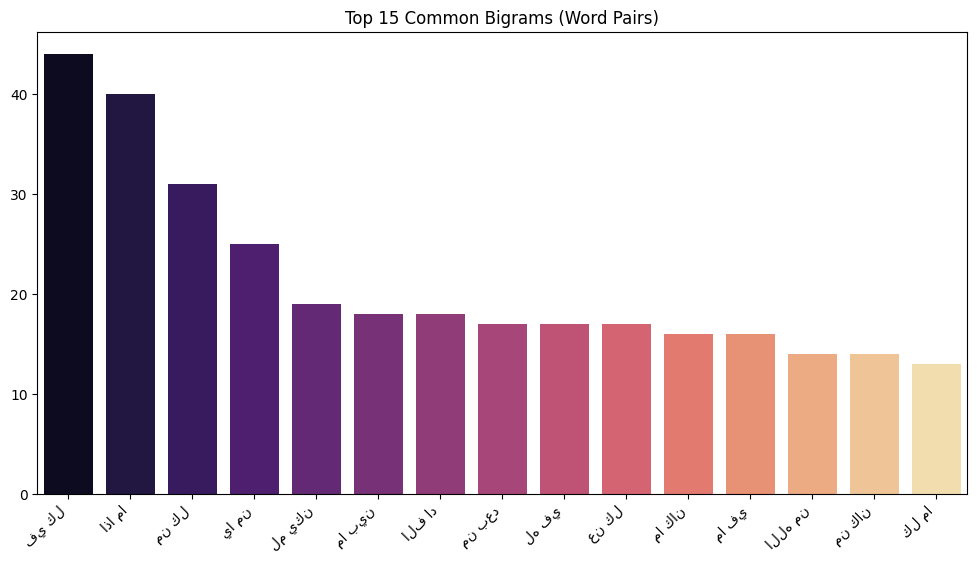

In [17]:
# 4. Bigram Analysis 
def get_top_bigrams(corpus, n=10):
    sample_size = 10000
    vec = CountVectorizer(ngram_range=(2, 2), max_features=2000).fit(corpus.sample(sample_size))
    bag_of_words = vec.transform(corpus.sample(sample_size))
    sum_words = bag_of_words.sum(axis=0) 
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)
    return words_freq[:n]

print("Analyzing Bigrams...")
top_bigrams = get_top_bigrams(df['clean_text'], n=15)
x_bigram, y_bigram = zip(*top_bigrams)

plt.figure(figsize=(12, 6))
sns.barplot(x=list(x_bigram), y=list(y_bigram), palette='magma')
plt.title('Top 15 Common Bigrams (Word Pairs)')
plt.xticks(rotation=45, ha='right')
plt.show()

## Generating Embeddings


In [18]:
from transformers import AutoTokenizer, AutoModelForMaskedLM

tokenizer = AutoTokenizer.from_pretrained("aubmindlab/bert-base-arabertv02")
model = AutoModelForMaskedLM.from_pretrained("aubmindlab/bert-base-arabertv02")
print("Loaded AraBERT tokenizer and model.")

Cancellation requested; stopping current tasks.


KeyboardInterrupt: 

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("aubmindlab/bert-base-arabertv02")
model = AutoModel.from_pretrained("aubmindlab/bert-base-arabertv02")
model.eval()

print("Loaded AraBERT tokenizer and encoder model.")

def get_mean_embedding(texts, max_len=128, device=None):
    """
    texts: list[str]
    returns: (len(texts), hidden_size) numpy array of mean-pooled embeddings
    """
    device = device or ("mps" if torch.mps.is_available() else "cpu")
    model.to(device)

    enc = tokenizer(
        texts,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=max_len
    ).to(device)

    with torch.no_grad():
        outputs = model(**enc)  

    last_hidden = outputs.last_hidden_state  
    attention_mask = enc["attention_mask"].unsqueeze(-1) 
    masked_hidden = last_hidden * attention_mask  

    # Mean-pool over non-padded tokens
    sums = masked_hidden.sum(dim=1)                   
    counts = attention_mask.sum(dim=1).clamp(min=1)     
    mean_pooled = (sums / counts).cpu().numpy()         
    return mean_pooled


BATCH_SIZE = 512
embeddings = []
texts = df["clean_text"].astype(str).tolist()

for i in range(0, len(texts), BATCH_SIZE):
    batch = texts[i:i+BATCH_SIZE]
    batch_emb = get_mean_embedding(batch, max_len=64)  
    embeddings.append(batch_emb)

import numpy as np
embeddings = np.vstack(embeddings)  


df["embedding"] = embeddings.tolist()


Loaded AraBERT tokenizer and encoder model.


In [27]:
df

,Unnamed: 0,العصر,البيت,الشاعر,clean_text,stopwords_removed_count,word_count,word_count_bin,embedding
88,88,عامي,م الهدب ولا الغرام يا اهيف جراحي قال لي القي ...,عائشة التيمورية,الهدب الغرام اهيف جراحي قال القي اقول ونام وال...,5,10,"(5, 10]","[-0.6050030589103699, 0.20500868558883667, -0...."
89,89,عامي,انا كخصرك نحيل والدمع راحي تخمينك اني عليل دا...,عائشة التيمورية,انا كخصرك نحيل والدمع راحي تخمينك اني عليل دا ...,1,10,"(5, 10]","[-0.37519416213035583, -0.20095448195934296, -..."
94,94,الحديث,هَمَّتِ الفُلكُ وَاِحتَواها الماءُ وَحَداها...,أحمد شوقي,همت الفلك واحتواها الما وحداها تقل الرجا,1,7,"(5, 10]","[-0.33089908957481384, -0.3120057284832001, 0...."
95,95,الحديث,ضَرَبَ البَحرُ ذو العُبابِ حَوالَي ها سَماء...,أحمد شوقي,ضرب البحر العباب حوالي سما اكبرتها السما,3,7,"(5, 10]","[-0.08421674370765686, 0.6783603429794312, 0.3..."
96,96,الحديث,وَرَأى المارِقونَ مِن شَرَكِ الأَر ضِ شِباك...,أحمد شوقي,وراي المارقون شرك الار شباكا تمدها الداما,2,7,"(5, 10]","[-0.17975108325481415, 0.46211543679237366, 0...."
...,...,...,...,...,...,...,...,...,...
777254,777254,الحديث,هي أغلى ما أنشأ اللَّه في الدنيا وأحلى قصيد...,شهاب غانم,اغلي انشا الله الدنيا واحلي قصيده تتغني,3,7,"(5, 10]","[-0.07875637710094452, 0.26269400119781494, 0...."
777255,777255,الحديث,هي أغرودة الأغاريد تنساب كحلم يغشى الجفون ا...,شهاب غانم,اغروده الاغاريد تنساب كحلم يغشي الجفون الوسني,1,7,"(5, 10]","[-0.6384330987930298, 0.48086315393447876, -0...."
777256,777256,الحديث,هي شلال بهجة وبهاء يتداعى وجداً ويخفق حسنا,شهاب غانم,شلال بهجه وبها يتداعي وجدا ويخفق حسنا,1,7,"(5, 10]","[-0.5271037220954895, 0.8971519470214844, 0.09..."
777257,777257,الحديث,هي حلم الهوى ومنطلقي الباقي يدك الحدود سجنا...,شهاب غانم,حلم الهوي ومنطلقي الباقي يدك الحدود سجنا فسجنا,1,8,"(5, 10]","[-0.8535467982292175, 0.6005125045776367, -0.1..."
